In [64]:
import seaborn as sns
import pandas as pd

In [65]:
df = pd.read_csv("output.txt")
df

,step,page,count,model_selection,model_score,arms_score,in_dram
0,1,140694874226688,0.0,0,0.000,0.0000,1
1,1,140695207673856,57057.0,0,0.000,0.0000,1
2,1,140695205576704,24024.0,0,0.000,0.0000,1
3,1,140695203479552,20020.0,0,0.000,0.0000,1
4,1,140695201382400,24024.0,0,0.000,0.0000,1
...,...,...,...,...,...,...,...
1572237,546,140665704939520,0.0,0,935.351,112.2710,0
1572238,546,140659245711360,0.0,0,935.351,58.8088,0
1572239,546,140665702842368,0.0,0,974.770,312.1940,0
1572240,546,140659243614208,0.0,0,935.351,107.0660,0


In [66]:
def set_target(group):
    group = group.sort_values("step")
    group["Target"] = group["count"].shift(-1)
    group = group.dropna()
    return group

df = df.groupby(["page"], group_keys=False).apply(
    set_target
).reset_index(drop=True)

/tmp/ipykernel_735751/2617714390.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["page"], group_keys=False).apply(


In [67]:
# Group by 'page' and 'step', then compute the exponentially weighted moving average (EWMA) over 'count'
ewma_df = (
    df.sort_values(['page', 'step'])
      .groupby('page')
      .apply(lambda x: x.set_index('step')['count'].ewm(span=5, adjust=False).mean())
      .reset_index()
      .rename(columns={'count': 'count_ewma'})
)

/tmp/ipykernel_735751/665497493.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.set_index('step')['count'].ewm(span=5, adjust=False).mean())


<Axes: xlabel='step', ylabel='page'>

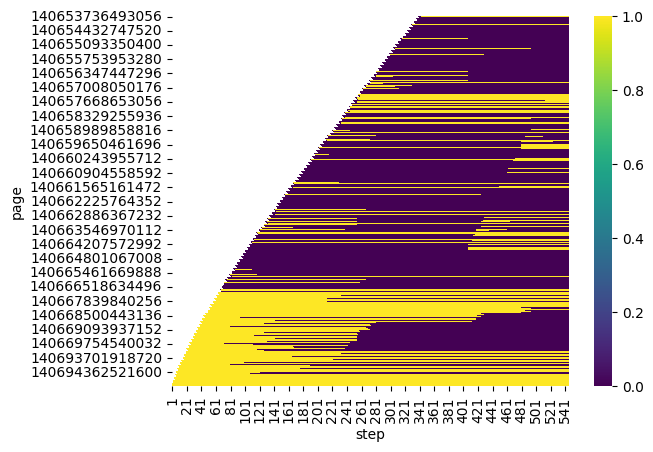

In [68]:
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df_pebs = df.pivot(index='page', columns='step', values='in_dram')

# Plot the heatmap
sns.heatmap(pivot_df_pebs, cmap='viridis', vmin=0, vmax=1)

<Axes: xlabel='step', ylabel='page'>

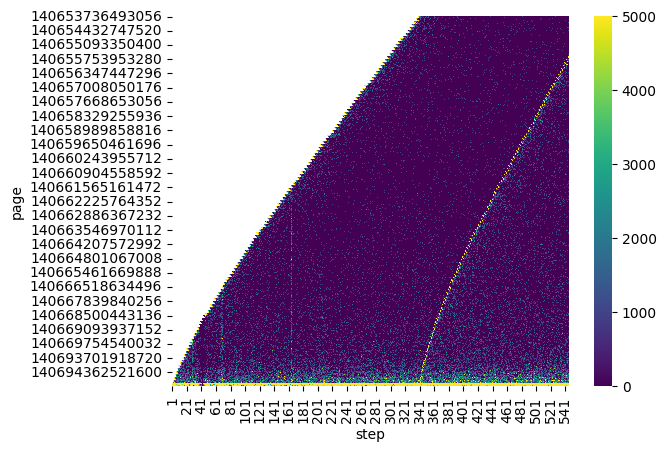

In [69]:
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df_pebs = df.pivot(index='page', columns='step', values='count')

# Plot the heatmap
sns.heatmap(pivot_df_pebs, cmap='viridis', vmin=0, vmax=5000)

Text(0.5, 1.0, 'Guradrail Model Selection Over Time')

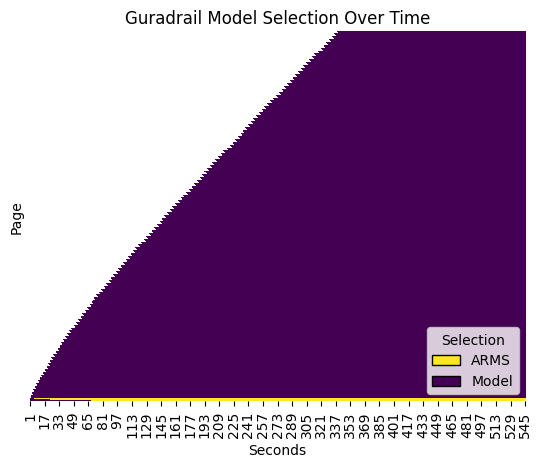

In [70]:
from matplotlib.patches import Patch

# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df = df.pivot(index='page', columns='step', values='model_selection')

# Plot the heatmap
import matplotlib.pyplot as plt

sns.heatmap(pivot_df, cmap='viridis', vmax=1, yticklabels=False, cbar=False).set(xlabel="Seconds", ylabel="Page")

# Add custom legend
legend_elements = [
    Patch(facecolor='#fde725', edgecolor='black', label='ARMS'),   # yellow from viridis
    Patch(facecolor='#440154', edgecolor='black', label='Model')   # purple from viridis
]
plt.legend(handles=legend_elements, loc='lower right', title="Selection")

plt.title("Guradrail Model Selection Over Time")

In [71]:
df["model_score"]

0               0.00
1            7651.49
2            9433.13
3            8697.44
4            6209.64
             ...    
1568213    440567.00
1568214    440567.00
1568215    440567.00
1568216    440567.00
1568217    584386.00
Name: model_score, Length: 1568218, dtype: float64

In [72]:
df["model_error"] = ((df["model_score"]) - df["count"]) / (df["count"].replace(0, 1))
df["arms_error"] = (df["arms_score"] - df["count"]) / (df["count"].replace(0, 1))

Text(0.5, 1.0, 'Predictive Accuracy of Model vs. Scaled PEBS')

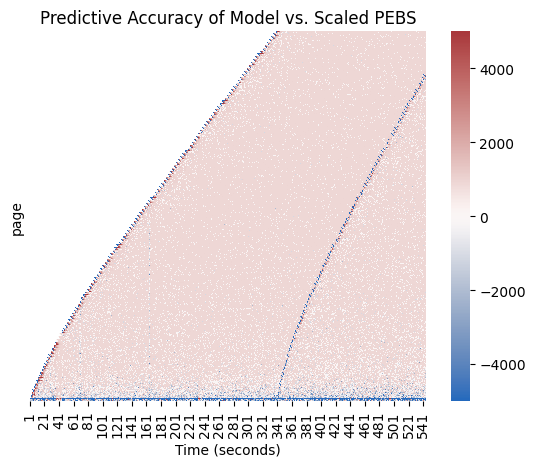

In [73]:
import matplotlib.pyplot as plt
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df_model = df.pivot(index='page', columns='step', values='model_score')

# Plot the heatmap
sns.heatmap(pivot_df_model - pivot_df_pebs, cmap='vlag', vmax=5000, vmin=-5000, yticklabels=False
).set(xlabel="Time (seconds)")
plt.title("Predictive Accuracy of Model vs. Scaled PEBS")

In [74]:
df[df["step"] > 10].sort_values(["step", "count"], ascending=[True, False])

,step,page,count,model_selection,model_score,arms_score,in_dram,Target,model_error,arms_error
1550788,11,140695142662144,16801800.0,0,2.017050e+07,1.280380e+07,1,16900900.0,0.200496,-0.237951
1567683,11,140695207673856,218218.0,0,1.910160e+05,1.749420e+05,1,225225.0,-0.124655,-0.198315
1446706,11,140694068920320,60060.0,0,1.015010e+04,1.879920e+04,1,8008.0,-0.831001,-0.686993
1555148,11,140695159439360,35035.0,1,2.930600e+04,3.514580e+04,1,53053.0,-0.163522,0.003163
1460091,11,140694121349120,34034.0,0,0.000000e+00,0.000000e+00,1,1001.0,-1.000000,-1.000000
...,...,...,...,...,...,...,...,...,...,...
1536663,545,140694752591872,0.0,0,1.476740e+03,2.935660e+03,1,2002.0,1476.740000,2935.660000
1537206,545,140694754689024,0.0,0,1.476740e+03,2.564620e+03,1,4004.0,1476.740000,2564.620000
1546437,545,140694790340608,0.0,0,1.004360e+03,8.700940e+02,1,3003.0,1004.360000,870.094000
1548606,545,140694798729216,0.0,0,1.799010e+03,2.960810e+03,1,3003.0,1799.010000,2960.810000


In [75]:
df[df["step"] > 10].sort_values(["step", "model_score"], ascending=[True, False])

,step,page,count,model_selection,model_score,arms_score,in_dram,Target,model_error,arms_error
1550788,11,140695142662144,16801800.0,0,2.017050e+07,1.280380e+07,1,16900900.0,0.200496,-0.237951
1567683,11,140695207673856,218218.0,0,1.910160e+05,1.749420e+05,1,225225.0,-0.124655,-0.198315
1555148,11,140695159439360,35035.0,1,2.930600e+04,3.514580e+04,1,53053.0,-0.163522,0.003163
1551333,11,140695144759296,30030.0,1,1.662230e+04,2.593300e+04,1,31031.0,-0.446477,-0.136430
1463837,11,140694203138048,0.0,0,1.494800e+04,1.964390e+04,1,4004.0,14948.000000,19643.900000
...,...,...,...,...,...,...,...,...,...,...
1474578,545,140694242983936,1001.0,0,9.353510e+02,4.310910e+02,1,1001.0,-0.065583,-0.569340
1475115,545,140694245081088,0.0,0,9.353510e+02,1.793460e+02,1,2002.0,935.351000,179.346000
1477263,545,140694253469696,1001.0,0,9.353510e+02,4.185840e+02,1,5005.0,-0.065583,-0.581834
1480479,545,140694266052608,0.0,0,9.353510e+02,3.245880e+02,0,0.0,935.351000,324.588000


Text(0.5, 1.0, 'Labeling Accuracy of Top 1000 Pages')

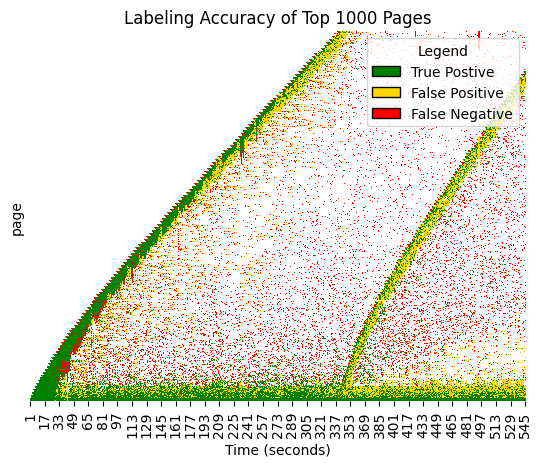

In [76]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

df = df.sort_values(["step", "Target"], ascending=[True, False])
result_df_top = df.groupby("step").head(500)
heatmap_data_true = result_df_top.copy().pivot_table(index='page', columns='step', values='Target', aggfunc=lambda x: 1 if len(x) > 0 else 0)
df = df.sort_values(["step", "model_score"], ascending=[True, False])
result_df_top = df.groupby("step").head(500)
heatmap_data_pred = result_df_top.copy().pivot_table(index='page', columns='step', values='model_score', aggfunc=lambda x: 1 if len(x) > 0 else 0)

#sns.heatmap((heatmap_data_pred.fillna(0) * 2 + heatmap_data_true.fillna(0) * 1).replace(0, np.nan), cmap="RdYlGn", cbar=False).set(ylabel="Block", xlabel="Time (seconds)")
#
# Create a custom colormap with a more intense yellow
colors = ["red", "gold", "green"]
cmap = LinearSegmentedColormap.from_list("custom_RdYlGn", colors, N=256)

sns.heatmap(
    (heatmap_data_pred.fillna(0) * 2 + heatmap_data_true.fillna(0) * 1).replace(0, np.nan),
    cmap=cmap,
    cbar=False,
    yticklabels=False
).set(xlabel="Time (seconds)")
# Add a custom legend
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='True Postive'),
    Patch(facecolor='gold', edgecolor='black', label='False Positive'),
    Patch(facecolor='red', edgecolor='black', label='False Negative')
]
plt.legend(handles=legend_elements, loc='upper right', title="Legend")
plt.title("Labeling Accuracy of Top 1000 Pages")

<Axes: xlabel='step', ylabel='page'>

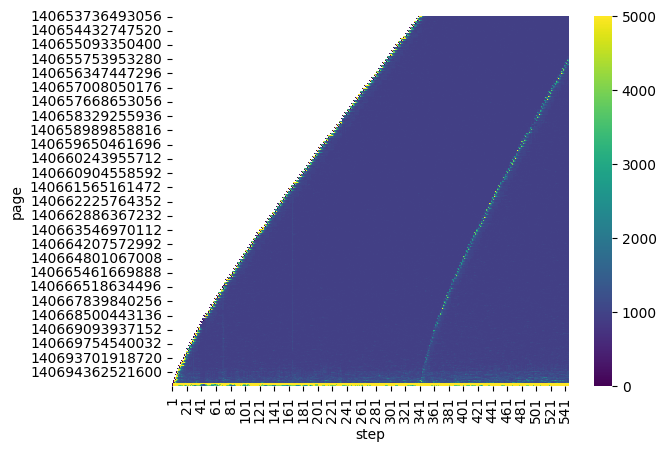

In [77]:
sns.heatmap(pivot_df_model, cmap='viridis', vmax=0, vmin=5000)

Text(0.5, 1.0, 'Predictive Accuracy of Arms vs. Scaled PEBS')

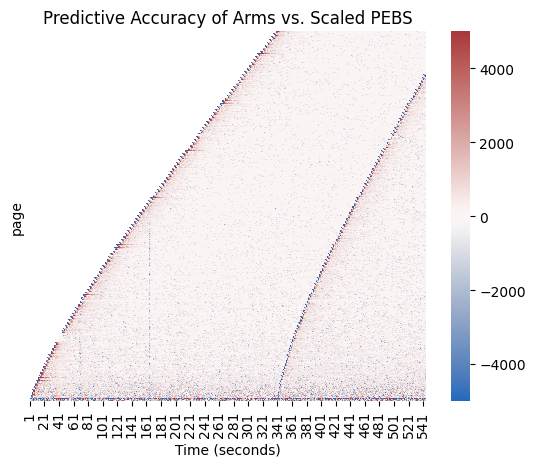

In [78]:
# Pivot the dataframe to create a matrix suitable for a heatmap
pivot_df_arms = df.pivot(index='page', columns='step', values='arms_score')

# Plot the heatmap
sns.heatmap(pivot_df_arms - pivot_df_pebs, cmap='vlag', vmax=5000, vmin=-5000,
    yticklabels=False
).set(xlabel="Time (seconds)")
plt.title("Predictive Accuracy of Arms vs. Scaled PEBS")

Text(0.5, 1.0, 'Labeling Accuracy of Top 500 Pages')

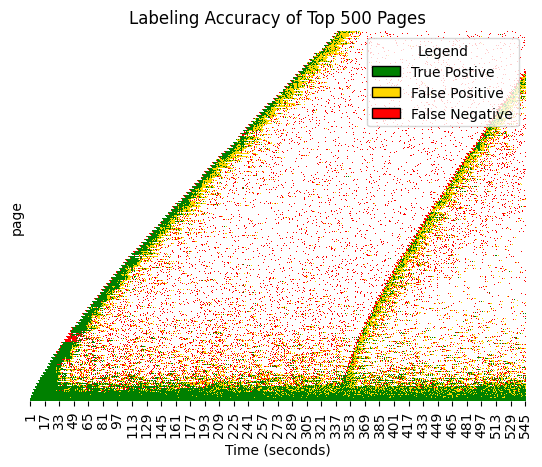

In [79]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

df = df.sort_values(["step", "Target"], ascending=[True, False])
result_df_top = df.groupby("step").head(500)
heatmap_data_true = result_df_top.pivot_table(index='page', columns='step', values='Target', aggfunc=lambda x: 1 if len(x) > 0 else 0)
df = df.sort_values(["step", "arms_score"], ascending=[True, False])
result_df_top = df.groupby("step").head(500)
heatmap_data_pred = result_df_top.pivot_table(index='page', columns='step', values='arms_score', aggfunc=lambda x: 1 if len(x) > 0 else 0)

#sns.heatmap((heatmap_data_pred.fillna(0) * 2 + heatmap_data_true.fillna(0) * 1).replace(0, np.nan), cmap="RdYlGn", cbar=False).set(ylabel="Block", xlabel="Time (seconds)")
#
# Create a custom colormap with a more intense yellow
colors = ["red", "gold", "green"]
cmap = LinearSegmentedColormap.from_list("custom_RdYlGn", colors, N=256)

sns.heatmap(
    (heatmap_data_pred.fillna(0) * 2 + heatmap_data_true.fillna(0) * 1).replace(0, np.nan),
    cmap=cmap,
    cbar=False,
    yticklabels=False
).set(xlabel="Time (seconds)")
# Add a custom legend
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='True Postive'),
    Patch(facecolor='gold', edgecolor='black', label='False Positive'),
    Patch(facecolor='red', edgecolor='black', label='False Negative')
]
plt.legend(handles=legend_elements, loc='upper right', title="Legend")
plt.title("Labeling Accuracy of Top 500 Pages")

<Axes: xlabel='step', ylabel='page'>

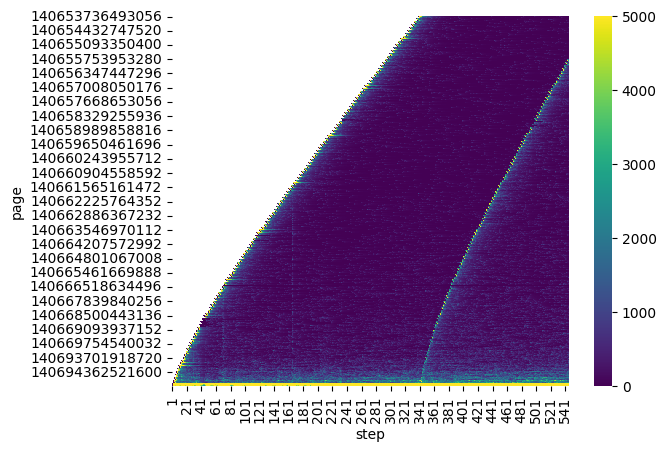

In [80]:
sns.heatmap(pivot_df_arms, cmap='viridis', vmax=5000, vmin=0)